# Porject Summary
### The dataset of this project is a CSV file containing hand landmarks (e.g., x, y, z coordinates of keypoints) extracted from the HaGRID dataset using MediaPipe. The output will be a trained machine learning model capable of classifying hand gestures into predefined classes. 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import mediapipe as mp
import joblib
from pathlib import Path
from collections import deque
from typing import Tuple, Optional
import warnings
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

In [3]:
df = pd.read_csv(r"C:\Users\Dell\Desktop\ml1-project\hand_landmarks_data .csv")
df.head()

,x1,y1,z1,x2,y2,z2,x3,y3,z3,x4,...,x19,y19,z19,x20,y20,z20,x21,y21,z21,label
0,262.669968,257.304901,-3.649205e-07,257.417542,247.109055,0.004224,246.882957,241.716827,0.005798,236.384537,...,223.345093,255.490692,-0.020450,215.043365,258.114746,-0.024577,208.006393,259.608673,-0.026722,call
1,83.351778,346.059113,-2.345265e-07,81.925037,328.562347,-0.011102,90.080132,311.535248,-0.021096,95.641823,...,132.451618,341.794434,-0.038175,142.773582,342.829254,-0.037336,152.431698,343.015991,-0.036136,call
2,187.756977,260.235492,-2.417307e-07,195.460579,241.506035,-0.000184,207.259529,223.674339,-0.009687,215.413628,...,250.301010,268.602938,-0.044068,262.425133,271.276638,-0.040469,272.989952,272.272231,-0.038301,call
3,114.976696,331.594238,-1.233261e-07,114.503494,320.549957,-0.002824,116.636627,310.080994,-0.008911,117.685066,...,145.195450,329.357544,-0.027622,151.053200,329.712341,-0.027863,155.990364,329.548828,-0.027723,call
4,188.795288,141.727867,-1.622995e-07,188.520905,127.947464,-0.002884,191.982880,111.010563,-0.008115,192.552521,...,226.696396,132.263248,-0.025113,234.831741,130.684147,-0.024087,241.587769,128.477188,-0.023486,call


In [4]:
df.describe()

,x1,y1,z1,x2,y2,z2,x3,y3,z3,x4,...,z18,x19,y19,z19,x20,y20,z20,x21,y21,z21
count,25675.000000,25675.000000,2.567500e+04,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000,...,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000
mean,201.958632,260.158527,1.272461e-07,202.517395,252.115322,-0.009465,202.862981,240.645966,-0.015946,203.025267,...,-0.024129,201.792374,227.455597,-0.033751,201.811275,227.802576,-0.032208,201.874802,227.807287,-0.028828
std,90.500333,76.533210,2.737932e-07,84.770933,75.384691,0.010376,80.412089,74.721921,0.013973,79.647588,...,0.015658,94.046497,77.231210,0.020453,93.664595,78.441253,0.020877,93.547017,79.963438,0.021136
min,-36.050926,45.722923,-2.029986e-06,7.184681,51.256840,-0.096630,25.114323,45.489950,-0.155846,23.446341,...,-0.201897,0.198635,20.146784,-0.286821,3.278137,32.158108,-0.286470,-4.537216,23.226204,-0.262047
25%,124.110329,205.815950,-5.243216e-08,130.535929,197.999625,-0.015199,136.711035,187.018583,-0.023020,138.905817,...,-0.030728,126.828913,172.720392,-0.042726,126.887403,172.345467,-0.041957,126.356627,172.083794,-0.039220
50%,199.667847,255.181793,1.497277e-07,199.979530,247.113892,-0.008737,200.092758,235.776978,-0.014231,200.482040,...,-0.020969,197.579865,221.781479,-0.029942,197.591736,222.381149,-0.028510,197.453270,222.485229,-0.025269
75%,266.428482,304.991663,2.989988e-07,261.147457,296.850769,-0.002783,255.876354,284.925993,-0.007134,254.622768,...,-0.013661,268.103920,273.190765,-0.019987,267.745743,274.196884,-0.017971,267.324657,275.805222,-0.014294
max,633.556020,781.674469,1.876254e-06,606.232386,751.869416,0.076365,598.541348,719.365010,0.094131,607.999801,...,0.031774,632.923029,779.419948,0.078105,638.134761,760.854103,0.104580,641.788521,760.554894,0.118668


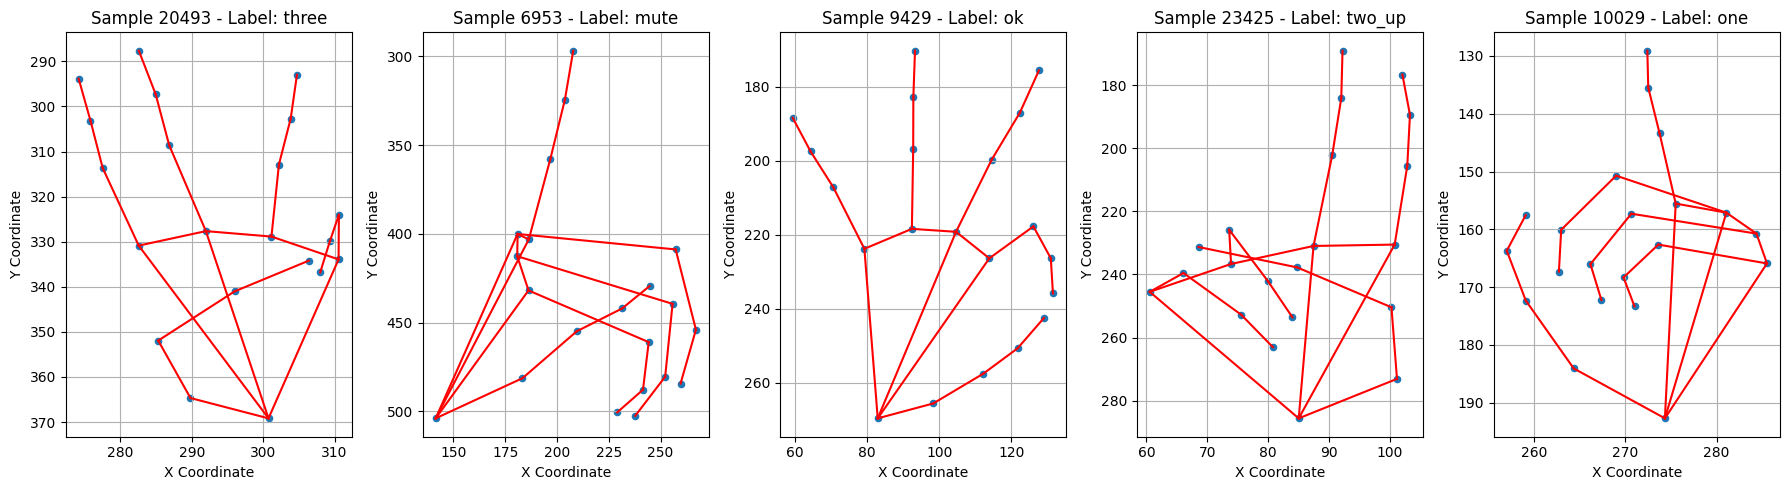

In [5]:
num_landmarks = 21

hand_connections = [
    (0, 1), (1, 2), (2, 3), (3, 4),
    (0, 5), (5, 6), (6, 7), (7, 8),
    (9, 10), (10, 11), (11, 12),
    (0, 9), (13, 14), (14, 15), (15, 16),
    (0, 17), (17, 18), (18, 19), (19, 20),
    (5, 9), (9, 13), (13, 17)
]

num_samples_to_plot = 5
samples_to_plot = df.sample(n=num_samples_to_plot)

plt.figure(figsize=(18, 5))

for i, (index, row) in enumerate(samples_to_plot.iterrows()):
    plt.subplot(1, num_samples_to_plot, i + 1)

    x_coords = []
    y_coords = []

    for j in range(1, num_landmarks + 1):
        x_coords.append(row[f'x{j}'])
        y_coords.append(row[f'y{j}'])

    plt.scatter(x_coords, y_coords, s=20)

    for connection in hand_connections:
        start_idx = connection[0]
        end_idx = connection[1]
        if start_idx < len(x_coords) and end_idx < len(x_coords):
            plt.plot(
                [x_coords[start_idx], x_coords[end_idx]],
                [y_coords[start_idx], y_coords[end_idx]],
                'r-'
            )

    plt.title(f'Sample {index} - Label: {row["label"]}')
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.grid(True)

    plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

## There is no major class imbalance that may affect the model performance

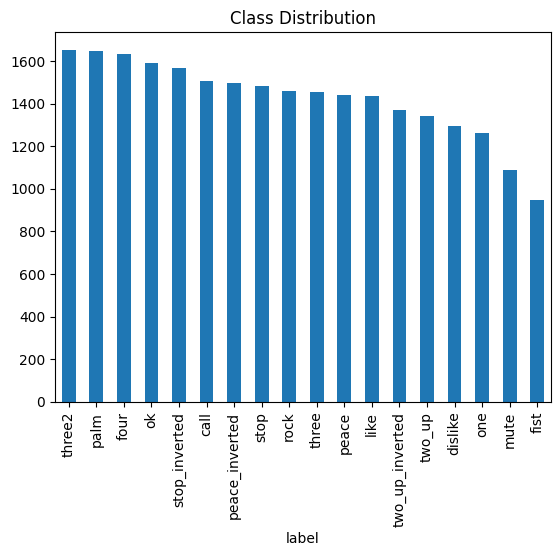

In [6]:
# checking for class imbalance
df['label'].value_counts().plot(kind='bar')
plt.title('Class Distribution')
plt.show()

# Data Preprocessing
#### 1. recenter the hand landmarks (x,y) to make the origin the wrist point and divide all the landmarks by the mid-finger tip position.
#### 2. Split data into train test split

In [7]:
wrist_x = df['x1']
wrist_y = df['y1']

mid_finger_tip_x_recenter = (df['x13'] - wrist_x)
mid_finger_tip_y_recenter = (df['y13'] - wrist_y)

for j in range(1, 22):
    df[f'x{j}'] = df[f'x{j}'] - wrist_x
    df[f'y{j}'] = df[f'y{j}'] - wrist_y

    df[f'x{j}'] = df[f'x{j}'] / mid_finger_tip_x_recenter
    df[f'y{j}'] = df[f'y{j}'] / mid_finger_tip_y_recenter

In [8]:
features = df.drop('label', axis=1)
label = df['label']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(features, label, test_size=0.2, random_state=42)

# Model training

##### 1. Random Forest Classifier

In [10]:
rf = RandomForestClassifier(random_state=42)
rf_search = GridSearchCV(estimator=rf, param_grid={'n_estimators': [100, 200, 250, 300]}, cv=3)
print("Starting GridSearchCV for Random Forest...")
rf_search.fit(X_train, y_train)
print("GridSearchCV for Random Forest completed.")
print(f"Best parameters for Random Forest: {rf_search.best_params_}")
print(f"Best cross-validation score for Random Forest: {rf_search.best_score_:.4f}")
rf = rf_search.best_estimator_
test_accuracy = rf.score(X_test, y_test)
print(f"Test accuracy of the best Random Forest model: {test_accuracy:.4f}")
y_pred_rf = rf.predict(X_test)

Starting GridSearchCV for Random Forest...
GridSearchCV for Random Forest completed.
Best parameters for Random Forest: {'n_estimators': 200}
Best cross-validation score for Random Forest: 0.9649
Test accuracy of the best Random Forest model: 0.9653


In [11]:
cl_rf = classification_report(y_test, y_pred_rf)
print(cl_rf)

                 precision    recall  f1-score   support

           call       0.98      0.99      0.99       287
        dislike       0.98      0.96      0.97       260
           fist       1.00      0.99      0.99       209
           four       0.96      0.91      0.94       325
           like       0.97      0.98      0.98       304
           mute       0.95      0.96      0.96       195
             ok       0.98      0.99      0.99       340
            one       0.96      0.95      0.95       248
           palm       0.92      0.96      0.94       317
          peace       0.94      0.95      0.95       276
 peace_inverted       0.99      0.94      0.96       307
           rock       0.99      0.98      0.99       290
           stop       0.93      0.96      0.94       293
  stop_inverted       0.97      0.97      0.97       309
          three       0.98      0.96      0.97       298
         three2       0.99      0.99      0.99       331
         two_up       0.95    

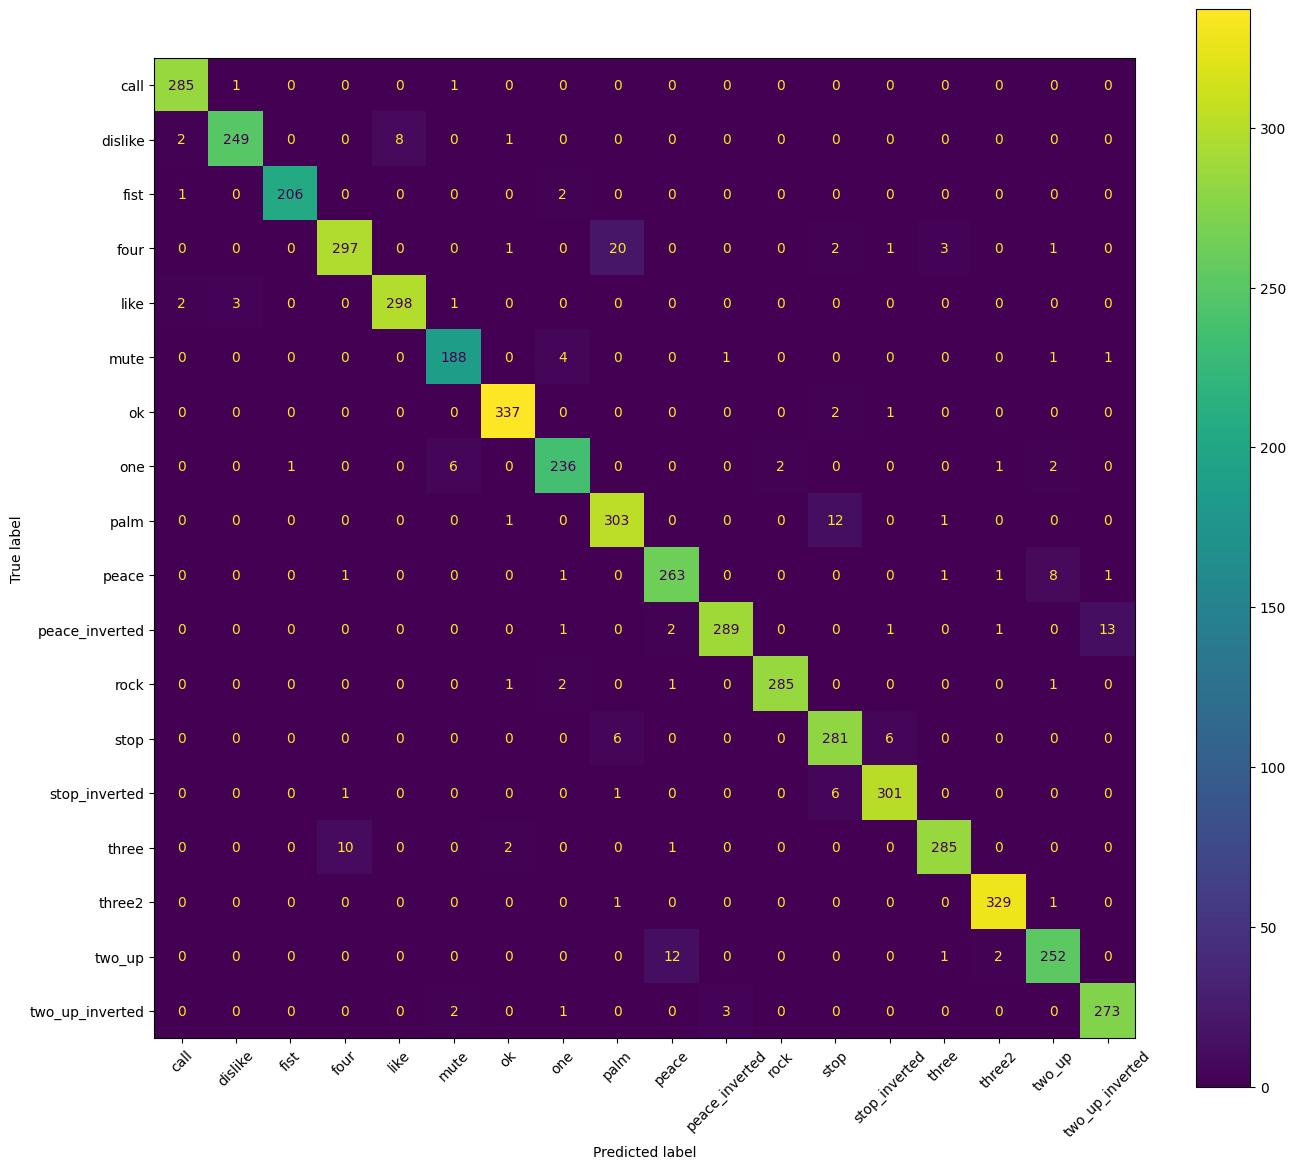

In [12]:
fig, ax = plt.subplots(figsize=(14, 12))

cm = confusion_matrix(y_test, y_pred_rf, labels=rf.classes_)
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf.classes_)
cm_display.plot(ax=ax, colorbar=True, xticks_rotation=45)

plt.tight_layout()
plt.show()

##### 2. Support Vector Machine

In [13]:
param_grid = {
    'C': [10,50,80,100,130],
    'gamma': [0.01, 0.05, 0.1, 1],
    'kernel': ['rbf']
}
svm_model = SVC(random_state=42)
grid_search = GridSearchCV(estimator=svm_model, param_grid=param_grid, cv = 3,n_jobs=-1,verbose=1)
print("Starting GridSearchCV for SVM...")
grid_search.fit(X_train, y_train)
print("GridSearchCV for SVM completed.")
print(f"Best parameters for SVM: {grid_search.best_params_}")
print(f"Best cross-validation score for SVM: {grid_search.best_score_:.4f}")
best_svm_model = grid_search.best_estimator_
test_accuracy = best_svm_model.score(X_test, y_test)
print(f"Test accuracy of the best SVM model: {test_accuracy:.4f}")
svm_predict = best_svm_model.predict(X_test)

Starting GridSearchCV for SVM...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
GridSearchCV for SVM completed.
Best parameters for SVM: {'C': 130, 'gamma': 0.01, 'kernel': 'rbf'}
Best cross-validation score for SVM: 0.9451
Test accuracy of the best SVM model: 0.9509


In [14]:
svm_report = classification_report(y_test, svm_predict)
print(svm_report)

                 precision    recall  f1-score   support

           call       0.99      0.94      0.97       287
        dislike       0.99      0.93      0.96       260
           fist       1.00      0.99      0.99       209
           four       0.96      0.93      0.95       325
           like       0.96      0.96      0.96       304
           mute       0.96      0.98      0.97       195
             ok       0.99      0.98      0.98       340
            one       0.98      0.91      0.94       248
           palm       0.97      0.97      0.97       317
          peace       0.96      0.93      0.95       276
 peace_inverted       0.99      0.98      0.98       307
           rock       1.00      0.97      0.98       290
           stop       0.94      0.89      0.92       293
  stop_inverted       0.66      0.97      0.79       309
          three       0.99      0.92      0.95       298
         three2       0.99      0.98      0.98       331
         two_up       0.98    

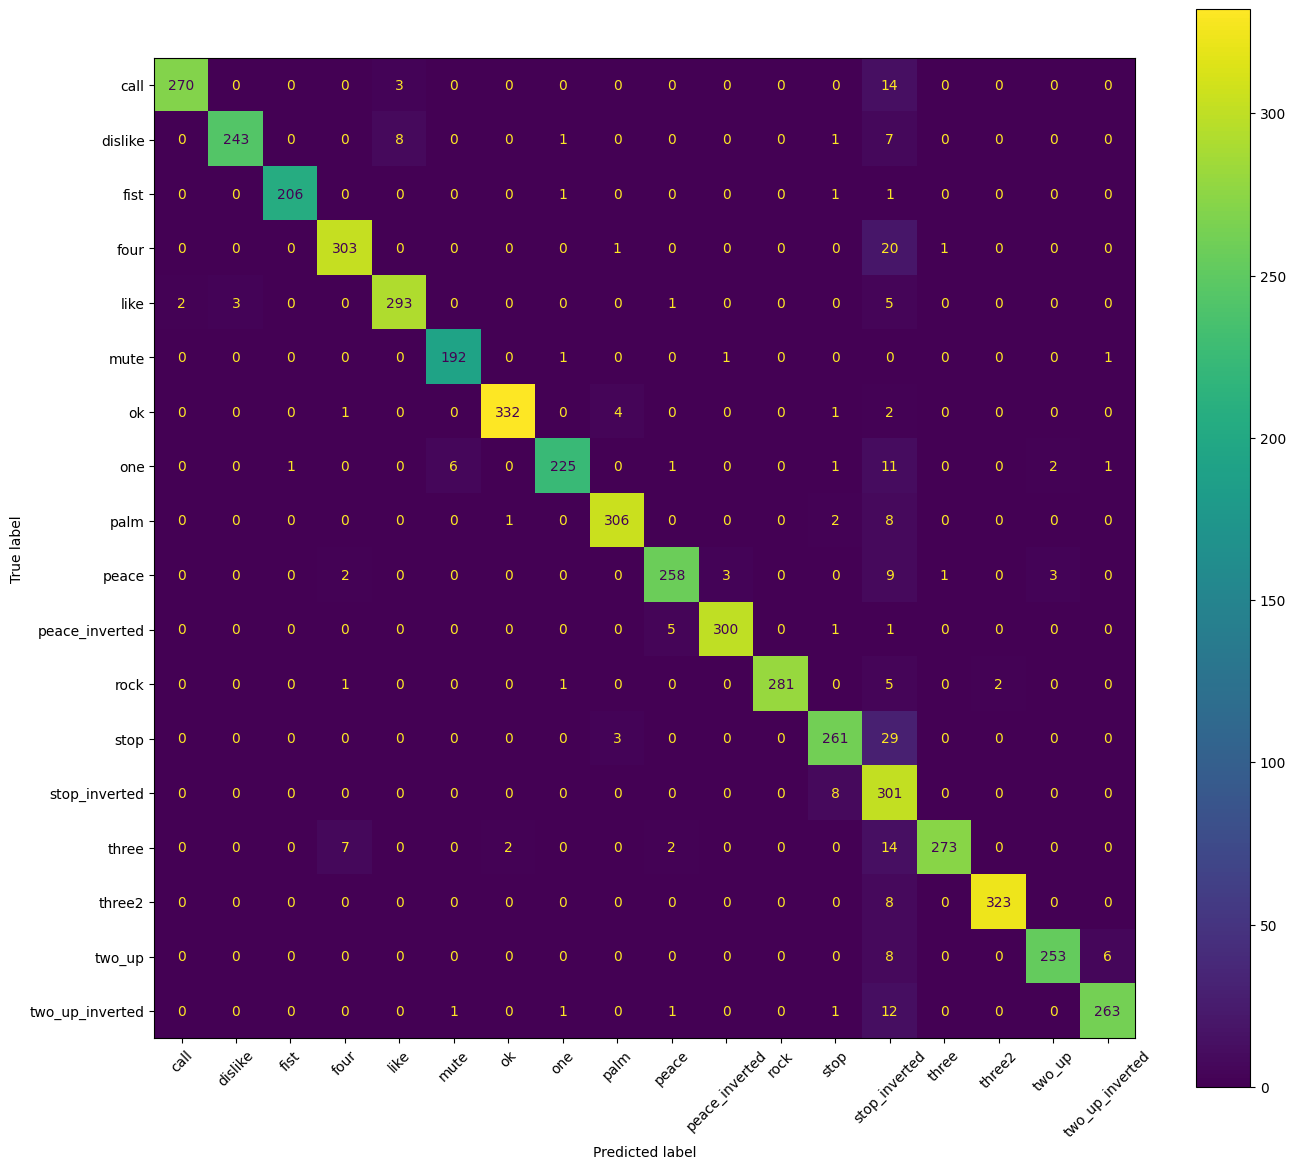

In [15]:
fig, ax = plt.subplots(figsize=(14, 12))

cm = confusion_matrix(y_test, svm_predict, labels=best_svm_model.classes_)
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_svm_model.classes_)
cm_display.plot(ax=ax, colorbar=True, xticks_rotation=45)

plt.tight_layout()
plt.show()

##### 3. AdaBoost

In [16]:
dt = DecisionTreeClassifier(max_depth=6, random_state=42)
param_grids={
    'n_estimators': [100, 300, 500],
    'learning_rate': [0.01, 0.1, 0.5],
    'estimator__max_depth': [1, 3, 5]
}
ab = AdaBoostClassifier(estimator= dt, random_state=42)
ab_search = GridSearchCV(estimator=ab, param_grid=param_grids, cv=3, n_jobs=-1, verbose=1)
print("Starting GridSearchCV for AdaBoost...")
ab_search.fit(X_train, y_train)
print("GridSearchCV for AdaBoost completed.")
print(f"Best parameters for AdaBoost: {ab_search.best_params_}")
print(f"Best cross-validation score for AdaBoost: {ab_search.best_score_:.4f}")
ab = ab_search.best_estimator_
ab_predict = ab.predict(X_test)

Starting GridSearchCV for AdaBoost...
Fitting 3 folds for each of 27 candidates, totalling 81 fits
GridSearchCV for AdaBoost completed.
Best parameters for AdaBoost: {'estimator__max_depth': 5, 'learning_rate': 0.5, 'n_estimators': 500}
Best cross-validation score for AdaBoost: 0.9567


In [17]:
cr = classification_report(y_test, ab_predict)
print(cr)

                 precision    recall  f1-score   support

           call       0.99      0.97      0.98       287
        dislike       0.98      0.95      0.97       260
           fist       0.99      0.99      0.99       209
           four       0.97      0.94      0.95       325
           like       0.96      0.99      0.98       304
           mute       0.94      0.96      0.95       195
             ok       0.99      0.99      0.99       340
            one       0.95      0.94      0.95       248
           palm       0.91      0.95      0.93       317
          peace       0.87      0.86      0.87       276
 peace_inverted       0.90      0.96      0.93       307
           rock       0.99      0.99      0.99       290
           stop       0.90      0.95      0.92       293
  stop_inverted       0.98      0.95      0.97       309
          three       0.99      0.96      0.97       298
         three2       0.99      0.97      0.98       331
         two_up       0.85    

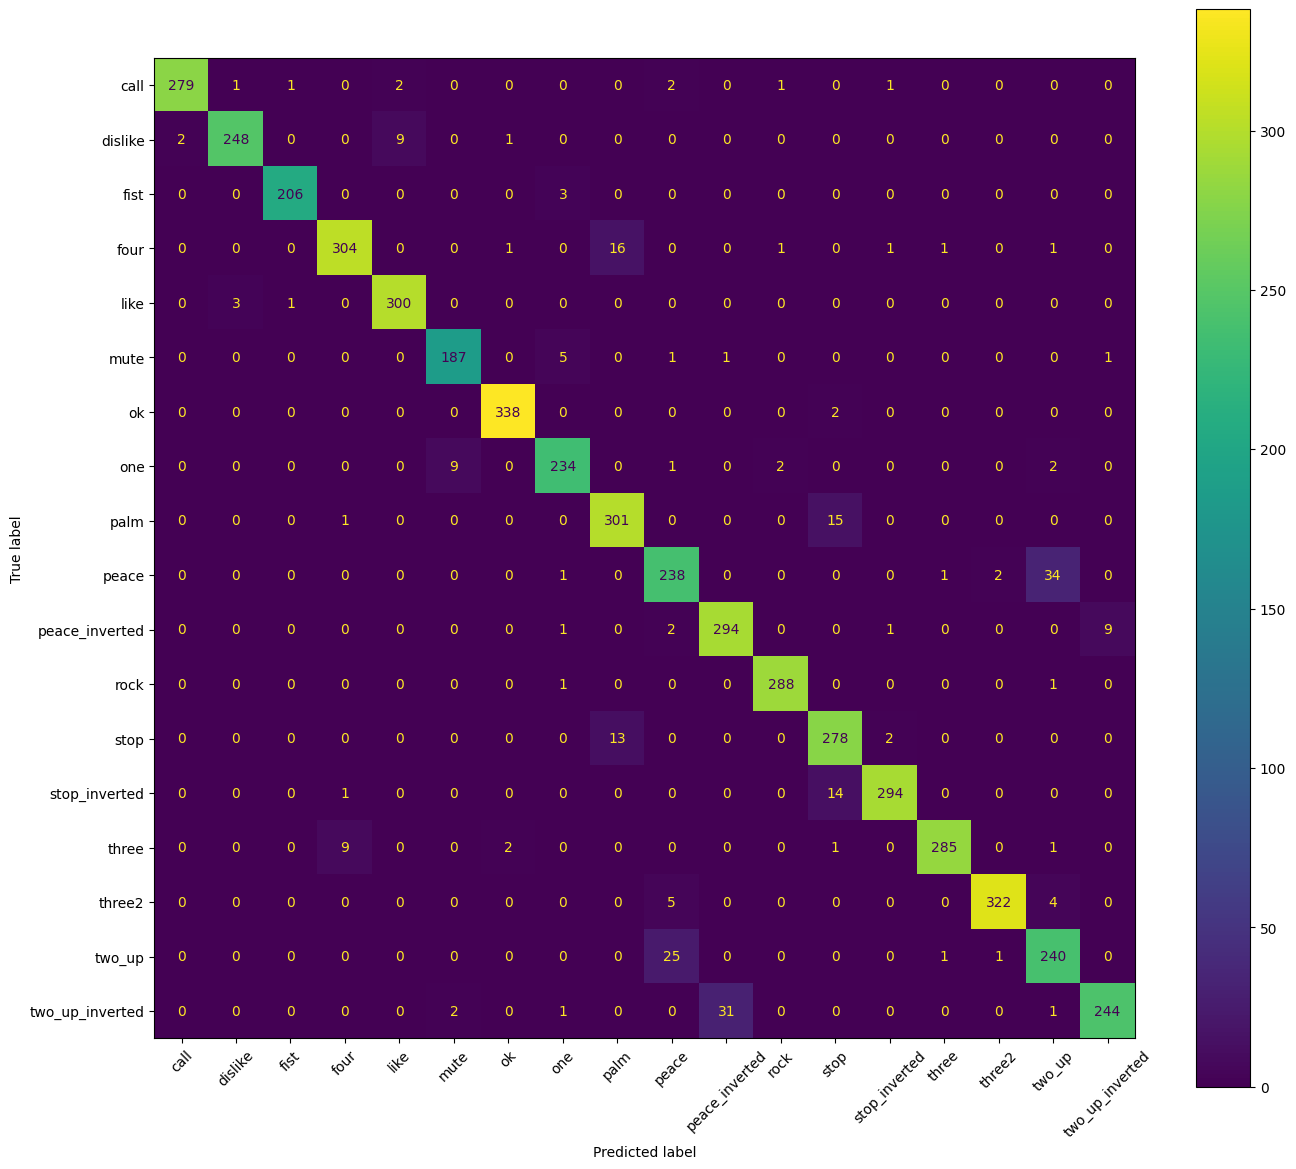

In [18]:
fig, ax = plt.subplots(figsize=(14, 12))

cm_ab = confusion_matrix(y_test, ab_predict, labels=ab.classes_)
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm_ab, display_labels=ab.classes_)
cm_display.plot(ax=ax, colorbar=True, xticks_rotation=45)

plt.tight_layout()
plt.show()

In [19]:
# save the best model
import joblib
joblib.dump(rf, 'random_forest_model.pkl')

['random_forest_model.pkl']

In [2]:
warnings.filterwarnings('ignore')

# Gesture classes
GESTURE_CLASSES = [
    'call', 'dislike', 'fist', 'four', 'like', 'mute', 'ok', 'one', 'palm',
    'peace', 'peace_inverted', 'rock', 'stop', 'stop_inverted', 'three',
    'three2', 'two_up', 'two_up_inverted'
]

# Hand skeleton connections for visualization
HAND_CONNECTIONS = [
    (0, 1), (1, 2), (2, 3), (3, 4),
    (0, 5), (5, 6), (6, 7), (7, 8),
    (0, 9), (9, 10), (10, 11), (11, 12),
    (0, 13), (13, 14), (14, 15), (15, 16),
    (0, 17), (17, 18), (18, 19), (19, 20),
    (5, 9), (9, 13), (13, 17)
]

In [ ]:
class GestureInference:
    
    def __init__(self, model_path: str, smoothing_window: int = 3):
        self.model_path = Path(model_path)
        
        if not self.model_path.exists():
            raise FileNotFoundError(f"Model not found: {self.model_path}")
        
        self.model = joblib.load(str(self.model_path))
        print(f"[OK] Model loaded: {self.model_path.name}")
        
        # MediaPipe setup
        self.mp_hands = mp.solutions.hands
        self.mp_drawing = mp.solutions.drawing_utils
        self.mp_drawing_styles = mp.solutions.drawing_styles
        self.hands = self.mp_hands.Hands(
            static_image_mode=False,
            max_num_hands=1,
            min_detection_confidence=0.6,
            min_tracking_confidence=0.5
        )
        
        # Smoothing
        self.pred_history = deque(maxlen=smoothing_window)
        self.conf_history = deque(maxlen=smoothing_window)
        
    def preprocess_landmarks(self, landmarks_3d: np.ndarray) -> Optional[np.ndarray]:
        try:
            landmarks = landmarks_3d.copy()
            
            # Step 1: Recenter at wrist (landmark 0)
            wrist = landmarks[0]
            wrist_x = wrist[0]
            wrist_y = wrist[1]
            
            # Step 2: Get middle finger tip recentered distance (landmark 12)
            mid_tip = landmarks[12]
            mid_tip_x_recenter = mid_tip[0] - wrist_x
            mid_tip_y_recenter = mid_tip[1] - wrist_y
            
            # Avoid division by zero
            if mid_tip_x_recenter == 0:
                mid_tip_x_recenter = 1.0
            if mid_tip_y_recenter == 0:
                mid_tip_y_recenter = 1.0
            
            # Step 3: Apply preprocessing to all landmarks
            # Recenter, then normalize by individual x and y distances (NOT Euclidean)
            for i in range(len(landmarks)):
                landmarks[i, 0] = (landmarks[i, 0] - wrist_x) / mid_tip_x_recenter
                landmarks[i, 1] = (landmarks[i, 1] - wrist_y) / mid_tip_y_recenter
            
            return landmarks.flatten()
        except Exception as e:
            print(f"Preprocessing error: {e}")
            return None
    
    def predict(self, landmarks_flat: np.ndarray) -> Tuple[str, float]:
        """Get gesture prediction."""
        try:
            pred_class = self.model.predict(landmarks_flat.reshape(1, -1))[0]
            
            # Get confidence
            if hasattr(self.model, 'predict_proba'):
                conf = float(np.max(self.model.predict_proba(landmarks_flat.reshape(1, -1))[0]))
            else:
                conf = 0.9
            
            if isinstance(pred_class, str):
                return pred_class, conf
            else:
                return GESTURE_CLASSES[int(pred_class)], conf
        except Exception as e:
            print(f"Prediction error: {e}")
            return "Unknown", 0.0
    
    def get_smoothed_result(self) -> Tuple[str, float]:
        """Get smoothed prediction."""
        if not self.pred_history:
            return "Waiting", 0.0
        
        gesture = max(set(self.pred_history), key=list(self.pred_history).count)
        conf = float(np.mean(list(self.conf_history)))
        
        return gesture, conf
    
    def draw_hand_and_gesture(self, frame: np.ndarray, hand_landmarks, gesture: str, conf: float) -> np.ndarray:
        """Draw landmarks using MediaPipe and gesture label."""
        h, w = frame.shape[:2]
        
        # Draw hand skeleton using MediaPipe drawing utils
        self.mp_drawing.draw_landmarks(
            frame,
            hand_landmarks,
            self.mp_hands.HAND_CONNECTIONS,
            self.mp_drawing_styles.get_default_hand_landmarks_style(),
            self.mp_drawing_styles.get_default_hand_connections_style()
        )
        
        # Draw gesture label
        lm_pts = [(int(lm.x * w), int(lm.y * h)) for lm in hand_landmarks.landmark]
        
        xs = [p[0] for p in lm_pts]
        ys = [p[1] for p in lm_pts]
        x_min, x_max = min(xs), max(xs)
        y_min, y_max = min(ys), max(ys)
        
        label = f"{gesture} ({conf:.2f})"
        font = cv2.FONT_HERSHEY_SIMPLEX
        fontScale = 0.8
        thickness = 2
        
        text_size = cv2.getTextSize(label, font, fontScale, thickness)[0]
        text_x = max(10, x_min)
        text_y = max(25, y_min - 10)
        
        # Background
        cv2.rectangle(frame, (text_x - 5, text_y - text_size[1] - 8),
                     (text_x + text_size[0] + 5, text_y + 5), (0, 200, 0), -1)
        cv2.putText(frame, label, (text_x, text_y), font, fontScale, (0, 0, 0), thickness)
        
        return frame
    
    def process_video(self, video_path: str, output_path: str = None, skip_frames: int = 1) -> str:

        video_path = Path(video_path)
        
        if not video_path.exists():
            raise FileNotFoundError(f"Video not found: {video_path}")
        
        if output_path is None:
            output_path = video_path.parent / f"output_{video_path.name}"
        else:
            output_path = Path(output_path)
        
        cap = cv2.VideoCapture(str(video_path))
        fps = int(cap.get(cv2.CAP_PROP_FPS))
        width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        
        print(f"[INFO] Video: {width}x{height} @ {fps}fps, {total} frames")
        print(f"[INFO] Processing every {skip_frames} frame(s) for speed...")
        
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        out = cv2.VideoWriter(str(output_path), fourcc, fps // skip_frames, (width, height))
        
        frame_idx = 0
        processed = 0
        
        try:
            while True:
                ret, frame = cap.read()
                if not ret:
                    break
                
                frame_idx += 1
                
                if frame_idx % skip_frames != 0:
                    continue
                
                processed += 1
                
                rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                results = self.hands.process(rgb)
                
                if results.multi_hand_landmarks:
                    hand_lm = results.multi_hand_landmarks[0]
                    lm_3d = np.array([[lm.x, lm.y, lm.z] for lm in hand_lm.landmark])
                    
                    lm_flat = self.preprocess_landmarks(lm_3d)
                    
                    if lm_flat is not None:
                        gesture, conf = self.predict(lm_flat)
                        self.pred_history.append(gesture)
                        self.conf_history.append(conf)
                        
                        
                        gesture_smooth, conf_smooth = self.get_smoothed_result()
                        if conf_smooth > 0.3:
                            frame = self.draw_hand_and_gesture(frame, hand_lm, gesture_smooth, conf_smooth)
                else:
                    self.pred_history.clear()
                    self.conf_history.clear()
                
                cv2.putText(frame, f"Frame: {processed}/{total // skip_frames}", (10, 30),
                           cv2.FONT_HERSHEY_SIMPLEX, 0.6, (200, 200, 200), 1)
                
                out.write(frame)
                
                if processed % 10 == 0:
                    print(f"[INFO] Processed {processed}/{total // skip_frames} frames...")
        
        except Exception as e:
            print(f"[ERROR] {e}")
        
        finally:
            cap.release()
            out.release()
            print(f"[OK] Output saved: {output_path}")
        
        return str(output_path)


In [ ]:
def main():
    """Main entry point."""
    try:
        PROJECT_DIR = Path(__file__).parent
    except NameError:
        PROJECT_DIR = Path.cwd()  

    # change these paths to your model and video locations
    model_path = PROJECT_DIR / "random_forest_model.pkl"

    video_file = Path(r"C:\Users\Dell\Pictures\Camera Roll\WIN_20260228_13_43_04_Pro.mp4")
    

    
    output_file = PROJECT_DIR / "gesture_demo.mp4"
    
    try:
        inference = GestureInference(str(model_path), smoothing_window=3)
        result_path = inference.process_video(
            str(video_file),
            str(output_file),
            skip_frames=1
        )
        print(f"\n[SUCCESS] Demo video created: {result_path}")
        print(f"[INFO] File size: {Path(result_path).stat().st_size / (1024*1024):.1f} MB")
    
    except Exception as e:
        print(f"[ERROR] {e}")


main()


[OK] Model loaded: random_forest_model.pkl
[INFO] Video: 1280x720 @ 29fps, 653 frames
[INFO] Processing every 2 frame(s) for speed...
[INFO] Processed 10/326 frames...
[INFO] Processed 20/326 frames...
[INFO] Processed 30/326 frames...
[INFO] Processed 40/326 frames...
[INFO] Processed 50/326 frames...
[INFO] Processed 60/326 frames...
[INFO] Processed 70/326 frames...
[INFO] Processed 80/326 frames...
[INFO] Processed 90/326 frames...
[INFO] Processed 100/326 frames...
[INFO] Processed 110/326 frames...
[INFO] Processed 120/326 frames...
[INFO] Processed 130/326 frames...
[INFO] Processed 140/326 frames...
[INFO] Processed 150/326 frames...
[INFO] Processed 160/326 frames...
[INFO] Processed 170/326 frames...
[INFO] Processed 180/326 frames...
[INFO] Processed 190/326 frames...
[INFO] Processed 200/326 frames...
[INFO] Processed 210/326 frames...
[INFO] Processed 220/326 frames...
[INFO] Processed 230/326 frames...
[INFO] Processed 240/326 frames...
[INFO] Processed 250/326 frames...


# Conclusion

#### In this notebook, three models have been trained. Random forset classifier model achieved the hightest f1 score of 97%. SVM and AdaBoost both socred f1 score of 95%. 